In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv('/content/train.csv')

In [ ]:
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))
print(df.info())

| Id   | MSSubClass   | MSZoning   | LotFrontage   | LotArea   | Street   | Alley   | LotShape   | LandContour   | Utilities   | LotConfig   | LandSlope   | Neighborhood   | Condition1   | Condition2   | BldgType   | HouseStyle   | OverallQual   | OverallCond   | YearBuilt   | YearRemodAdd   | RoofStyle   | RoofMatl   | Exterior1st   | Exterior2nd   | MasVnrType   | MasVnrArea   | ExterQual   | ExterCond   | Foundation   | BsmtQual   | BsmtCond   | BsmtExposure   | BsmtFinType1   | BsmtFinSF1   | BsmtFinType2   | BsmtFinSF2   | BsmtUnfSF   | TotalBsmtSF   | Heating   | HeatingQC   | CentralAir   | Electrical   | 1stFlrSF   | 2ndFlrSF   | LowQualFinSF   | GrLivArea   | BsmtFullBath   | BsmtHalfBath   | FullBath   | HalfBath   | BedroomAbvGr   | KitchenAbvGr   | KitchenQual   | TotRmsAbvGrd   | Functional   | Fireplaces   | FireplaceQu   | GarageType   | GarageYrBlt   | GarageFinish   | GarageCars   | GarageArea   | GarageQual   | GarageCond   | PavedDrive   | WoodDeckSF   | OpenPorchSF 

In [ ]:
descriptive_stats = df.describe()
print("Descriptive Statistics")
print(descriptive_stats.to_markdown(numalign="left", stralign="left"))

Descriptive Statistics
|       | Id      | MSSubClass   | LotFrontage   | LotArea   | OverallQual   | OverallCond   | YearBuilt   | YearRemodAdd   | MasVnrArea   | BsmtFinSF1   | BsmtFinSF2   | BsmtUnfSF   | TotalBsmtSF   | 1stFlrSF   | 2ndFlrSF   | LowQualFinSF   | GrLivArea   | BsmtFullBath   | BsmtHalfBath   | FullBath   | HalfBath   | BedroomAbvGr   | KitchenAbvGr   | TotRmsAbvGrd   | Fireplaces   | GarageYrBlt   | GarageCars   | GarageArea   | WoodDeckSF   | OpenPorchSF   | EnclosedPorch   | 3SsnPorch   | ScreenPorch   | PoolArea   | MiscVal   | MoSold   | YrSold   | SalePrice   |
|:------|:--------|:-------------|:--------------|:----------|:--------------|:--------------|:------------|:---------------|:-------------|:-------------|:-------------|:------------|:--------------|:-----------|:-----------|:---------------|:------------|:---------------|:---------------|:-----------|:-----------|:---------------|:---------------|:---------------|:-------------|:--------------|:-------

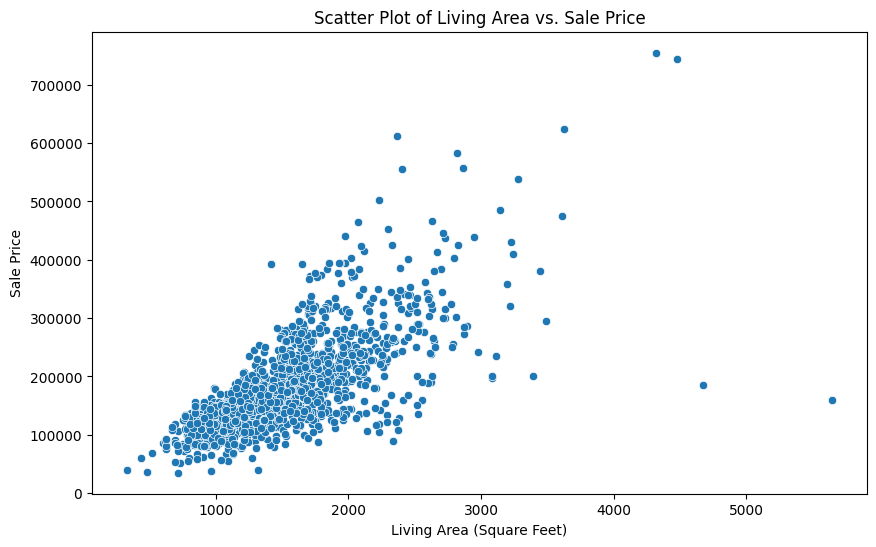

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title('Scatter Plot of Living Area vs. Sale Price')
plt.xlabel('Living Area (Square Feet)')
plt.ylabel('Sale Price')
plt.show()


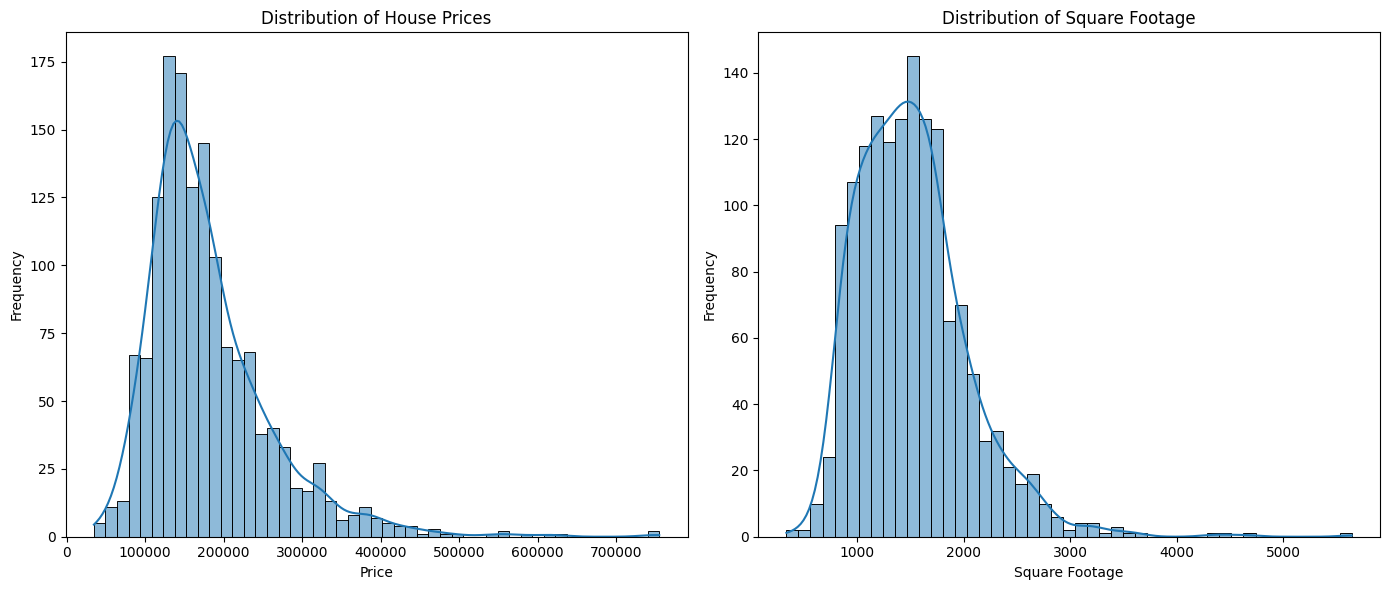

In [ ]:

# Create a figure and two subplots side by side
plt.figure(figsize=(14, 6))

# First subplot - Distribution of House Prices
plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

# Second subplot - Distribution of Square Footage
plt.subplot(1, 2, 2)
sns.histplot(df['GrLivArea'], kde=True)
plt.title('Distribution of Square Footage')
plt.xlabel('Square Footage')
plt.ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

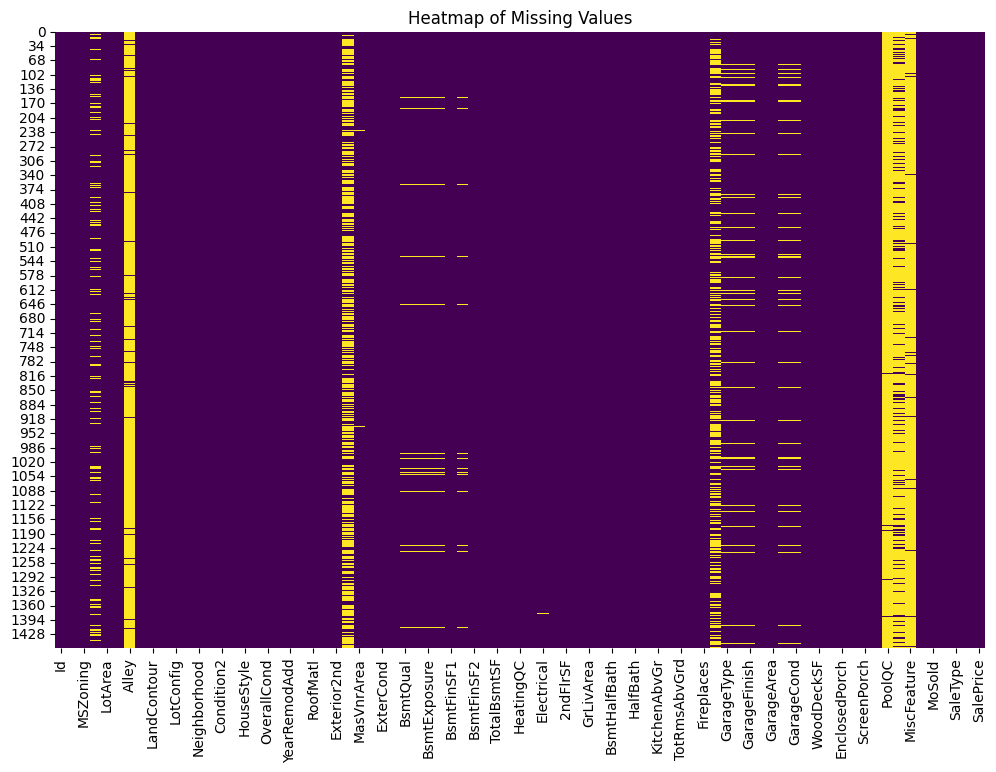

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()


In [ ]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


In [ ]:
# Dropping columns with too many missing values
columns_to_drop = ['Alley', 'PoolQC', 'Fence', 'MiscFeature']

df_cleaned = df.drop(columns=columns_to_drop)

In [ ]:
remaining_missing_values = df_cleaned.isnull().sum()
remaining_missing_values = remaining_missing_values[remaining_missing_values > 0]
print(remaining_missing_values)


LotFrontage     259
MasVnrType      872
MasVnrArea        8
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
FireplaceQu     690
GarageType       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64


In [ ]:
#numerical values
df_cleaned['LotFrontage'].fillna(df_cleaned['LotFrontage'].median(), inplace=True)
df_cleaned['MasVnrArea'].fillna(df_cleaned['MasVnrArea'].median(), inplace=True)
df_cleaned['GarageYrBlt'].fillna(df_cleaned['GarageYrBlt'].median(), inplace=True)


In [ ]:
#catgorical values
df_cleaned['MasVnrType'].fillna(df_cleaned['MasVnrType'].mode()[0], inplace=True)
df_cleaned['BsmtQual'].fillna(df_cleaned['BsmtQual'].mode()[0], inplace=True)
df_cleaned['BsmtCond'].fillna(df_cleaned['BsmtCond'].mode()[0], inplace=True)
df_cleaned['BsmtExposure'].fillna(df_cleaned['BsmtExposure'].mode()[0], inplace=True)
df_cleaned['BsmtFinType1'].fillna(df_cleaned['BsmtFinType1'].mode()[0], inplace=True)
df_cleaned['BsmtFinType2'].fillna(df_cleaned['BsmtFinType2'].mode()[0], inplace=True)
df_cleaned['Electrical'].fillna(df_cleaned['Electrical'].mode()[0], inplace=True)
df_cleaned['FireplaceQu'].fillna(df_cleaned['FireplaceQu'].mode()[0], inplace=True)
df_cleaned['GarageType'].fillna(df_cleaned['GarageType'].mode()[0], inplace=True)
df_cleaned['GarageFinish'].fillna(df_cleaned['GarageFinish'].mode()[0], inplace=True)
df_cleaned['GarageQual'].fillna(df_cleaned['GarageQual'].mode()[0], inplace=True)
df_cleaned['GarageCond'].fillna(df_cleaned['GarageCond'].mode()[0], inplace=True)


In [ ]:
print(df_cleaned.isnull().sum().sum())

0


In [ ]:
df_cleaned['HouseAge'] = df_cleaned['YrSold'] - df_cleaned['YearBuilt']
df_cleaned['Remodeled'] = (df_cleaned['YearRemodAdd'] != df_cleaned['YearBuilt']).astype(int)
df_cleaned['TotalPorchArea'] = (df_cleaned['OpenPorchSF'] +
                                df_cleaned['EnclosedPorch'] +
                                df_cleaned['3SsnPorch'] +
                                df_cleaned['ScreenPorch'])
df_cleaned['YearsSinceRemodel'] = df_cleaned['YrSold'] - df_cleaned['YearRemodAdd']
df_cleaned['TotalBathrooms'] = df_cleaned['FullBath'] + (0.5 * df_cleaned['HalfBath']) + df_cleaned['BsmtFullBath'] + (0.5 * df_cleaned['BsmtHalfBath'])


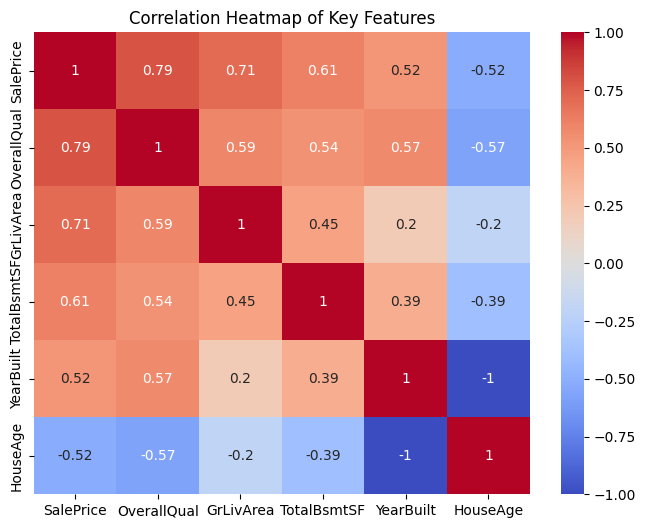

In [ ]:
key_features = ['SalePrice', 'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt', 'HouseAge']  # Add more if needed
correlation_matrix = df_cleaned[key_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Key Features')
plt.show()


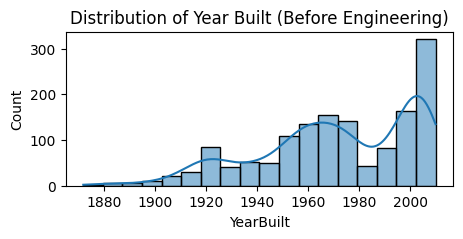

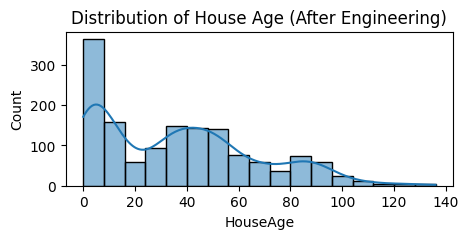

In [ ]:
# Before Feature Engineering
plt.figure(figsize=(5, 2))
sns.histplot(df_cleaned['YearBuilt'], kde=True)
plt.title('Distribution of Year Built (Before Engineering)')
plt.show()

# After Feature Engineering (e.g., HouseAge)
plt.figure(figsize=(5, 2))
sns.histplot(df_cleaned['HouseAge'], kde=True)
plt.title('Distribution of House Age (After Engineering)')
plt.show()


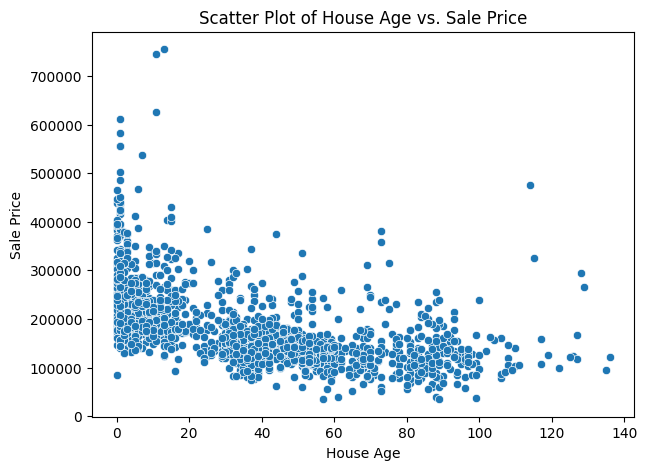

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='HouseAge', y='SalePrice', data=df_cleaned)
plt.title('Scatter Plot of House Age vs. Sale Price')
plt.xlabel('House Age')
plt.ylabel('Sale Price')
plt.show()


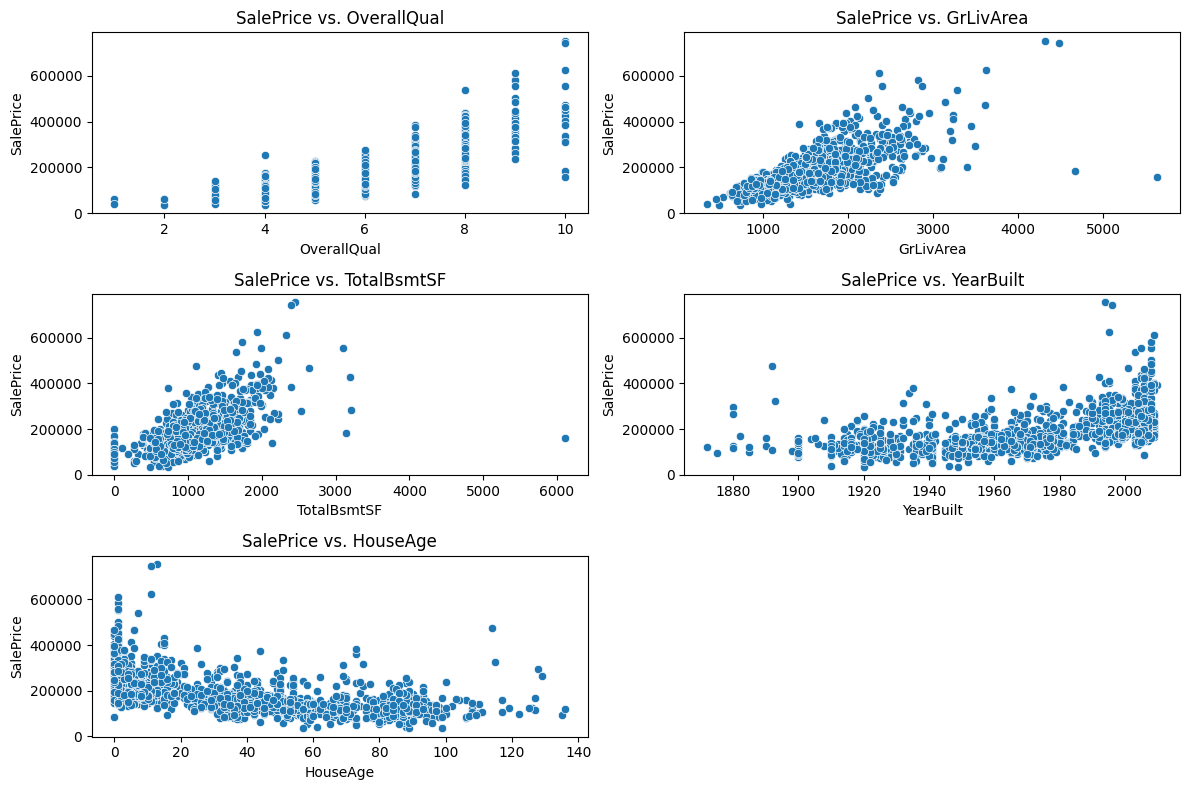

In [ ]:
# List of key features
key_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt', 'HouseAge']

# Create scatter plots for each key feature vs. SalePrice
plt.figure(figsize=(12, 8))

for i, feature in enumerate(key_features):
    plt.subplot(3, 2, i + 1)  # Adjust subplot grid to fit all plots
    # Use df_cleaned instead of df to access 'HouseAge'
    sns.scatterplot(x=df_cleaned[feature], y=df_cleaned['SalePrice'])
    plt.title(f'SalePrice vs. {feature}')
    plt.xlabel(feature)
    plt.ylabel('SalePrice')

plt.tight_layout()
plt.show()

In [ ]:
# Create a copy of the cleaned dataframe before encoding
df_encoded = df_cleaned.copy()

# Perform one-hot encoding on all categorical columns
df_encoded = pd.get_dummies(df_encoded, drop_first=True)

# Now df_encoded will be your dataset with all categorical variables encoded

In [ ]:
test_data= pd.read_csv('/content/test.csv')

In [ ]:
print(test_data.head().to_markdown(index=False, numalign="left", stralign="left"))


| Id   | MSSubClass   | MSZoning   | LotFrontage   | LotArea   | Street   | Alley   | LotShape   | LandContour   | Utilities   | LotConfig   | LandSlope   | Neighborhood   | Condition1   | Condition2   | BldgType   | HouseStyle   | OverallQual   | OverallCond   | YearBuilt   | YearRemodAdd   | RoofStyle   | RoofMatl   | Exterior1st   | Exterior2nd   | MasVnrType   | MasVnrArea   | ExterQual   | ExterCond   | Foundation   | BsmtQual   | BsmtCond   | BsmtExposure   | BsmtFinType1   | BsmtFinSF1   | BsmtFinType2   | BsmtFinSF2   | BsmtUnfSF   | TotalBsmtSF   | Heating   | HeatingQC   | CentralAir   | Electrical   | 1stFlrSF   | 2ndFlrSF   | LowQualFinSF   | GrLivArea   | BsmtFullBath   | BsmtHalfBath   | FullBath   | HalfBath   | BedroomAbvGr   | KitchenAbvGr   | KitchenQual   | TotRmsAbvGrd   | Functional   | Fireplaces   | FireplaceQu   | GarageType   | GarageYrBlt   | GarageFinish   | GarageCars   | GarageArea   | GarageQual   | GarageCond   | PavedDrive   | WoodDeckSF   | OpenPorchSF 

In [ ]:
print(test_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [ ]:
missing_values = test_data.isnull().sum()
missing_values[missing_values > 0]

,0
MSZoning,4
LotFrontage,227
Alley,1352
Utilities,2
Exterior1st,1
Exterior2nd,1
MasVnrType,894
MasVnrArea,15
BsmtQual,44
BsmtCond,45


In [ ]:
columns_to_drop = ['Alley', 'PoolQC', 'Fence', 'MiscFeature']

test_cleaned = test_data.drop(columns=columns_to_drop)

In [ ]:
test_cleaned['LotFrontage'].fillna(test_cleaned['LotFrontage'].median(), inplace=True)
test_cleaned['MasVnrArea'].fillna(test_cleaned['MasVnrArea'].median(), inplace=True)
test_cleaned['GarageYrBlt'].fillna(test_cleaned['GarageYrBlt'].median(), inplace=True)


In [ ]:
test_cleaned['MasVnrType'].fillna(test_cleaned['MasVnrType'].mode()[0], inplace=True)
test_cleaned['BsmtQual'].fillna(test_cleaned['BsmtQual'].mode()[0], inplace=True)
test_cleaned['BsmtCond'].fillna(test_cleaned['BsmtCond'].mode()[0], inplace=True)
test_cleaned['BsmtExposure'].fillna(test_cleaned['BsmtExposure'].mode()[0], inplace=True)
test_cleaned['BsmtFinType1'].fillna(test_cleaned['BsmtFinType1'].mode()[0], inplace=True)
test_cleaned['BsmtFinType2'].fillna(test_cleaned['BsmtFinType2'].mode()[0], inplace=True)
test_cleaned['Electrical'].fillna(test_cleaned['Electrical'].mode()[0], inplace=True)
test_cleaned['FireplaceQu'].fillna(test_cleaned['FireplaceQu'].mode()[0], inplace=True)
test_cleaned['GarageType'].fillna(test_cleaned['GarageType'].mode()[0], inplace=True)
test_cleaned['GarageFinish'].fillna(test_cleaned['GarageFinish'].mode()[0], inplace=True)
test_cleaned['GarageQual'].fillna(test_cleaned['GarageQual'].mode()[0], inplace=True)
test_cleaned['GarageCond'].fillna(test_cleaned['GarageCond'].mode()[0], inplace=True)


In [ ]:
print(test_cleaned.isnull().sum().sum())

22


In [ ]:
remaining_missing_values = test_cleaned.isnull().sum()
print(remaining_missing_values[remaining_missing_values > 0])

MSZoning        4
Utilities       2
Exterior1st     1
Exterior2nd     1
BsmtFinSF1      1
BsmtFinSF2      1
BsmtUnfSF       1
TotalBsmtSF     1
BsmtFullBath    2
BsmtHalfBath    2
KitchenQual     1
Functional      2
GarageCars      1
GarageArea      1
SaleType        1
dtype: int64


In [ ]:
# Filling missing categorical values with mode
categorical_columns = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']

for column in categorical_columns:
    test_cleaned[column].fillna(test_cleaned[column].mode()[0], inplace=True)


In [ ]:
# Filling missing numerical values with median
numerical_columns = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']

for column in numerical_columns:
    test_cleaned[column].fillna(test_cleaned[column].median(), inplace=True)


In [ ]:
print(test_cleaned.isnull().sum().sum())


0


In [ ]:
test_cleaned['HouseAge'] = test_cleaned['YrSold'] - test_cleaned['YearBuilt']
test_cleaned['Remodeled'] = (test_cleaned['YearRemodAdd'] != test_cleaned['YearBuilt']).astype(int)
test_cleaned['TotalPorchArea'] = (test_cleaned['OpenPorchSF'] +
                                test_cleaned['EnclosedPorch'] +
                                test_cleaned['3SsnPorch'] +
                                test_cleaned['ScreenPorch'])
test_cleaned['YearsSinceRemodel'] = test_cleaned['YrSold'] - test_cleaned['YearRemodAdd']
test_cleaned['TotalBathrooms'] = test_cleaned['FullBath'] + (0.5 * test_cleaned['HalfBath']) + test_cleaned['BsmtFullBath'] + (0.5 * test_cleaned['BsmtHalfBath'])

In [ ]:
# Create a copy of the cleaned dataframe before encoding
test_encoded = test_cleaned.copy()

# Perform one-hot encoding on all categorical columns
test_encoded = pd.get_dummies(test_encoded, drop_first=True)

# Now test_encoded will be your dataset with all categorical variables encoded


In [ ]:
X_train = df_encoded.drop(columns=['SalePrice'])  # Training features
y_train = df_encoded['SalePrice']                # Target variable
X_test = test_encoded.drop(columns=['Id'])       # Test features (without the Id column)


In [ ]:
# 1. Align the features between training and test sets
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 2. Train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# 3. Make predictions on the aligned test data
test_predictions_lr = linear_model.predict(X_test)



In [ ]:
# 1. Split training data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# 2. Train the model on the training split
model = LinearRegression()
model.fit(X_train_split, y_train_split)

# 3. Evaluate the model on the validation set
y_val_pred = model.predict(X_val_split)
mse = mean_squared_error(y_val_split, y_val_pred)
r2 = r2_score(y_val_split, y_val_pred)
print(f'Mean Squared Error on Validation Set: {mse:.2f}')
print(f'R-squared on Validation Set: {r2:.2f}')

# 4. Train on the full training data and predict on the test set
model.fit(X_train, y_train)
test_predictions = model.predict(X_test)


Mean Squared Error on Validation Set: 2746766461.71
R-squared on Validation Set: 0.64


In [ ]:
# 1. Train the Decision Tree Regressor on the training split
regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train_split, y_train_split)

# 2. Make predictions on the validation data
y_val_pred = regressor.predict(X_val_split)

# 3. Calculate MSE and R-squared on the validation set
mse_tree = mean_squared_error(y_val_split, y_val_pred)
r2_tree = r2_score(y_val_split, y_val_pred)

print(f'Mean Squared Error on Validation Set: {mse_tree:.2f}')
print(f'R-squared on Validation Set: {r2_tree:.2f}')


Mean Squared Error on Validation Set: 1771402811.02
R-squared on Validation Set: 0.77


In [ ]:
# Step 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Hyperparameter Tuning with RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200],  # Reduce the number of estimators
    'max_depth': [10, 20],       # Limit the max depth
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),
                                   param_distributions=param_distributions,
                                   n_iter=10,  # Number of parameter settings that are sampled
                                   cv=5,
                                   n_jobs=-1,
                                   scoring='neg_mean_squared_error')

random_search.fit(X_train_scaled, y_train)
best_model = random_search.best_estimator_

# Step 3: Split Data into Training and Validation Sets for Evaluation

# Split your data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42)

# Train the best model on the training split
best_model.fit(X_train_split, y_train_split)

# Evaluate the model on the validation set
y_val_pred = best_model.predict(X_val_split)
mse_forest = mean_squared_error(y_val_split, y_val_pred)
r2_forest = r2_score(y_val_split, y_val_pred)
print(f'Mean Squared Error on Validation Set: {mse_forest:.2f}')
print(f'R-squared on Validation Set: {r2_forest:.2f}')

# Step 4: Train on Full Training Data and Predict on Test Set

# Retrain the best model on the full training data
best_model.fit(X_train_scaled, y_train)

# Predict on the test data
test_predictions_forest = best_model.predict(X_test_scaled)

# Step 5: Prepare the Submission

submission = pd.DataFrame({
    'Id': test_encoded['Id'],
    'SalePrice': test_predictions_forest
})

submission.to_csv('submission_forest.csv', index=False)

Mean Squared Error on Validation Set: 821594718.23
R-squared on Validation Set: 0.89


In [ ]:
#Project Completed